In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:98%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li, div.text_cell_render p{width:95% !important;font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
table td, th{font-size:16px;}
table{ margin-left:0 !important;   /* 왼쪽 여백 0 */}
</style>
"""))

<font size="5" color="red"><b>ch2. 군집분석</b></font>
# 1절. 군집모델(클러스터링)
- 클러스터(cluster) : 독립변수의 특성이 유사한 데이터의 그룹
- 클러스터링(clustering) : 주어진 데이터를 여러 개의 클러스터로 구분하는 것
1) 중심 기반 클러스터링(K-Means)
<img src="https://upload.wikimedia.org/wikipedia/commons/e/e5/KMeans-Gaussian-data.svg"
style="display: block; margin-left: 0; width: 20%;">
2) 연결기반 클러스터링(DBSCAN) 
<img src="https://upload.wikimedia.org/wikipedia/commons/0/05/DBSCAN-density-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">
3) 밀도기반 클러스터링(DBSCAN의 변형으로 OPTICS) 
<img src="https://upload.wikimedia.org/wikipedia/commons/8/8a/OPTICS-Gaussian-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">

# 2절. K-Means 클러스터링
- 가장 단순하고 빠른 클러스터링 알고리즘의 하나
- 목적함수 값이 최소화될 때까지 클러스터의 중심(centroid) 𝜇k와 각 데이터가 소속될 클러스터를 반복해서 찾는 것
- K-Means 클러스터링의 세부 알고리즘
    1. 임의의 중심값 μk를 고릅니다.(보통 데이터 샘플 중의 하나를 선택합니다.)
    2. 중심에서 각 샘플 데이터까지의 거리를 계산합니다.
    3. 각 데이터 샘플에서 가장 가까운 중심을 선택하여 클러스터 갱신합니다.
    4. 다시 만들어진 클러스터에 대해 중심을 다시 계산하고 1~4를 반복합니다.

In [2]:
import matplotlib.pyplot as plt
# plt.rc('font', family='Malgun Gothic')
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글깨짐 방지
plt.rcParams['axes.unicode_minus'] = False    # 축의 - 깨짐 방지
plt.rcParams['figure.figsize'] = (15,4) # 모든 시각화 사이즈

In [3]:
# 분류를 위한 가상 데이터 셋 생성
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=20, # 데이터 갯수(기본값100) : 20행
                          n_features=2,  # 독립변수 갯수(기본값20)
                          n_informative=2, # 독립변수 중 종속변수에 영향을 주는 독립변수 갯수(기본값2)
                          n_redundant=0,   # 종속변수에 영향을 안 미치는 독립변수 갯수(기본값2)
                          n_classes=2,     # 종속변수의 클래스 수(0, 1)
                          n_clusters_per_class=1, # 각 클래스 당 군의 갯수(서브그룹이 없음)
                          random_state=123)
X.shape, y.shape

((20, 2), (20,))

In [4]:
# 5:5로 분류되었는지 확인
import numpy as np
value, count = np.unique(y, return_counts=True)
{v:c for v, c in zip(value, count)}

{0: 10, 1: 10}

In [5]:
np.column_stack([X, y])[:3] # np.c_[X, y]

array([[ 1.03859554,  2.51175389,  0.        ],
       [ 1.00271366,  1.93521549,  0.        ],
       [-1.6881048 ,  0.02599427,  1.        ]])

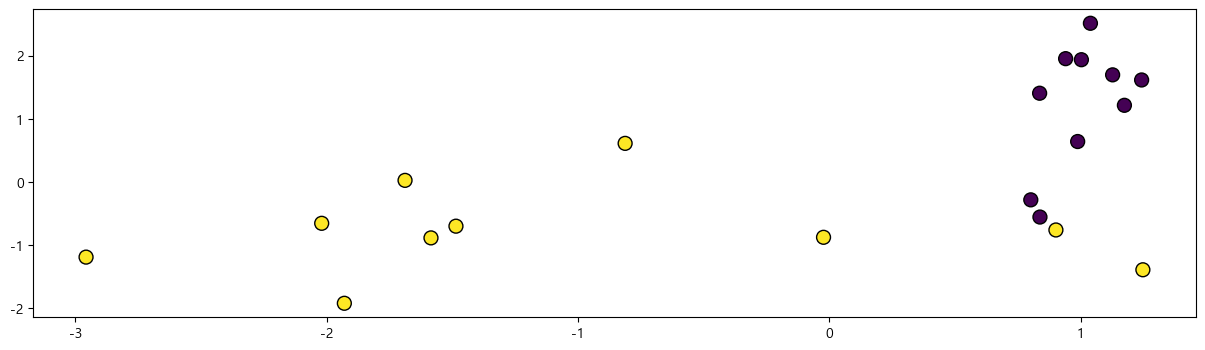

In [6]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=100, edgecolors='k')
plt.show()

In [7]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 군의 갯수
              init='k-means++', # 초기중심점이 서로 멀리 떨어지도록 똑똑하게 초기화/'random'
              max_iter=300, # 각 실행에서 최대 300번 중심점 이동(중심점이 이동되지 않으면 300까지 안 해)
              n_init='auto'
              )
model.fit(X)

KMeans(n_clusters=2, n_init='auto')

In [8]:
c0, c1 = model.cluster_centers_ # 모델이 선정한 두 클러스터의 중심점
c0, c1

(array([0.99879248, 1.2131753 ]), array([-1.0352032 , -0.77291498]))

In [13]:
print('실제값 :', y)
pred = model.predict
print('예측값 :', pred)
labels= model.labels_
print('라벨:',labels)

실제값 : [0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0]
예측값 : <bound method _BaseKMeans.predict of KMeans(n_clusters=2, n_init='auto')>
라벨: [0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0]
